In [18]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [19]:
df_clean = pd.read_csv('../data/data_clean.csv')
print(df_clean.columns)
df_labels = df_clean.copy()[['class_primary','class_secondary','attack']]
df_names = df_clean['english_name']
df_data = df_clean.drop(columns=['english_name','class_primary','class_secondary','attack'])

Index(['gen', 'english_name', 'percent_male', 'percent_female', 'height_m',
       'weight_kg', 'capture_rate', 'base_egg_steps', 'hp', 'attack',
       'defense', 'sp_attack', 'sp_defense', 'speed', 'against_normal',
       'against_fire', 'against_water', 'against_electric', 'against_grass',
       'against_ice', 'against_fighting', 'against_poison', 'against_ground',
       'against_flying', 'against_psychict', 'against_bug', 'against_rock',
       'against_ghost', 'against_dragon', 'against_dark', 'against_steel',
       'against_fairy', 'votes_first', 'votes_top_6', 'num_abilities',
       'evo_length', 'has_mega_evolution', 'has_gigantamax', 'rarity',
       'class_primary', 'class_secondary'],
      dtype='object')


### Linear regression model with hand picking features

In [20]:

# Prepare features and target
X = df_data
y = df_labels['attack']

# Add constant for intercept
X_const = sm.add_constant(X.select_dtypes(include=[np.number]))

# Fit OLS linear regression
model = sm.OLS(y, X_const).fit()

# Show model summary
print(model.summary())
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print("Variance Inflation Factor (VIF) for each variable:")
print(vif_data.sort_values('VIF', ascending=False))

                            OLS Regression Results                            
Dep. Variable:                 attack   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     30.80
Date:                Mon, 27 Oct 2025   Prob (F-statistic):          1.72e-131
Time:                        19:15:36   Log-Likelihood:                -3939.0
No. Observations:                 898   AIC:                             7954.
Df Residuals:                     860   BIC:                             8137.
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 57.7686     13

In [21]:
# Drop 'against_dragon' from X_const and recalculate VIF
X_const_vif = X_const.drop(columns=['votes_top_6','against_dragon','against_flying','against_ground','base_egg_steps','against_dark','against_fighting'])

vif_data_new = pd.DataFrame()
vif_data_new["feature"] = X_const_vif.columns
vif_data_new["VIF"] = [variance_inflation_factor(X_const_vif.values, i) for i in range(X_const_vif.shape[1])]

print("Variance Inflation Factor (VIF) after dropping 'against_dragon':")
print(vif_data_new.sort_values('VIF', ascending=False))

Variance Inflation Factor (VIF) after dropping 'against_dragon':
               feature         VIF
0                const  200.907954
15    against_electric    2.575098
14       against_water    2.545685
20         against_bug    2.352365
6         capture_rate    2.345896
5            weight_kg    2.238502
21        against_rock    2.211051
12      against_normal    2.207650
18      against_poison    2.124882
30              rarity    2.123467
9            sp_attack    2.117636
13        against_fire    2.111721
8              defense    2.108416
4             height_m    2.081772
10          sp_defense    1.990937
16       against_grass    1.886641
2         percent_male    1.859696
3       percent_female    1.805562
7                   hp    1.797683
19    against_psychict    1.714109
11               speed    1.644489
24       against_fairy    1.611081
23       against_steel    1.574580
22       against_ghost    1.551961
17         against_ice    1.501155
25         votes_first   

In [22]:
# Refit OLS linear regression using X_const_vif and attack as target
model_vif = sm.OLS(y, X_const_vif).fit()
print(model_vif.summary())

                            OLS Regression Results                            
Dep. Variable:                 attack   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     36.24
Date:                Mon, 27 Oct 2025   Prob (F-statistic):          3.29e-131
Time:                        19:15:36   Log-Likelihood:                -3953.0
No. Observations:                 898   AIC:                             7968.
Df Residuals:                     867   BIC:                             8117.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 21.2342      9

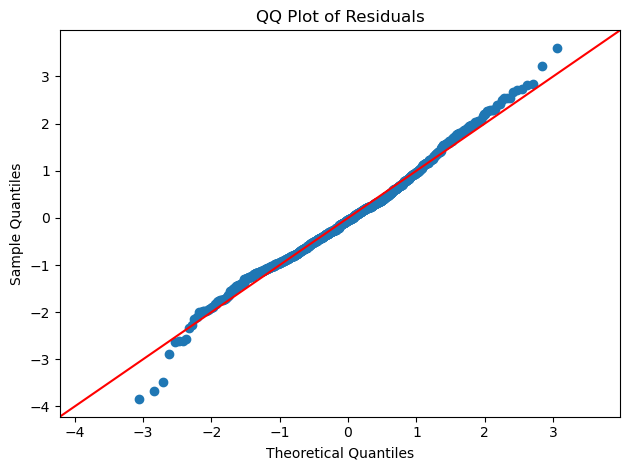

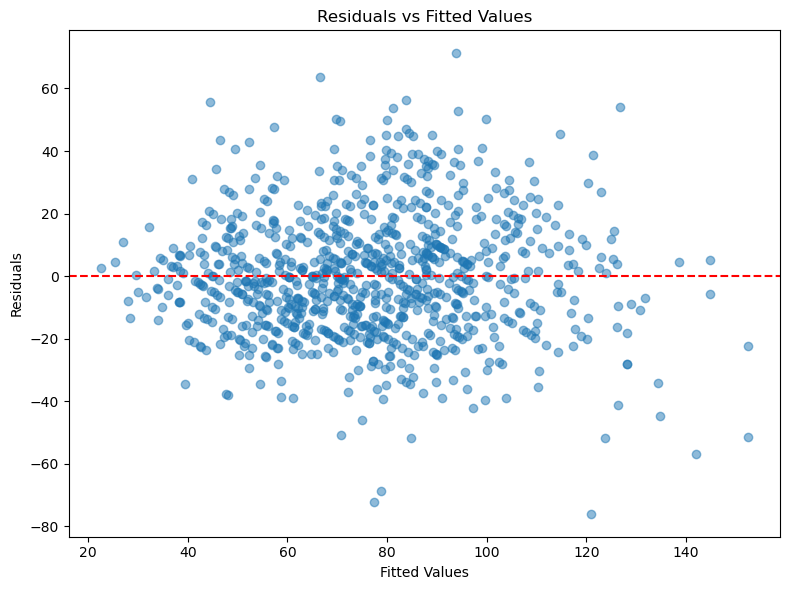

In [23]:
# QQ plot of residuals
residuals = model_vif.resid
sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

# Residual plot (fitted values vs residuals)
fitted = model_vif.fittedvalues
plt.figure(figsize=(8, 6))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                 attack   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     56.50
Date:                Mon, 27 Oct 2025   Prob (F-statistic):          8.91e-138
Time:                        19:15:37   Log-Likelihood:                -3959.3
No. Observations:                 898   AIC:                             7959.
Df Residuals:                     878   BIC:                             8055.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 14.2424      7

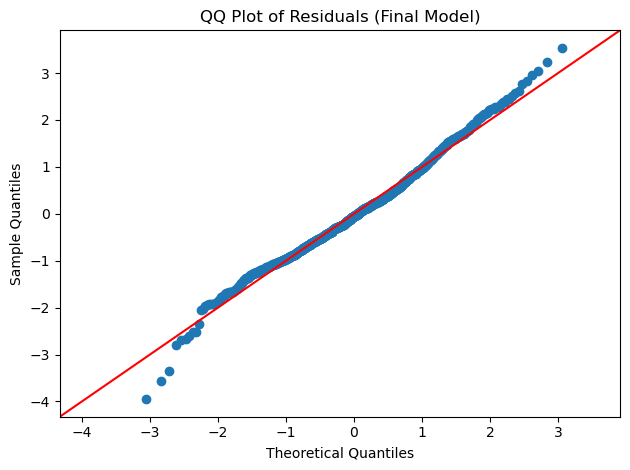

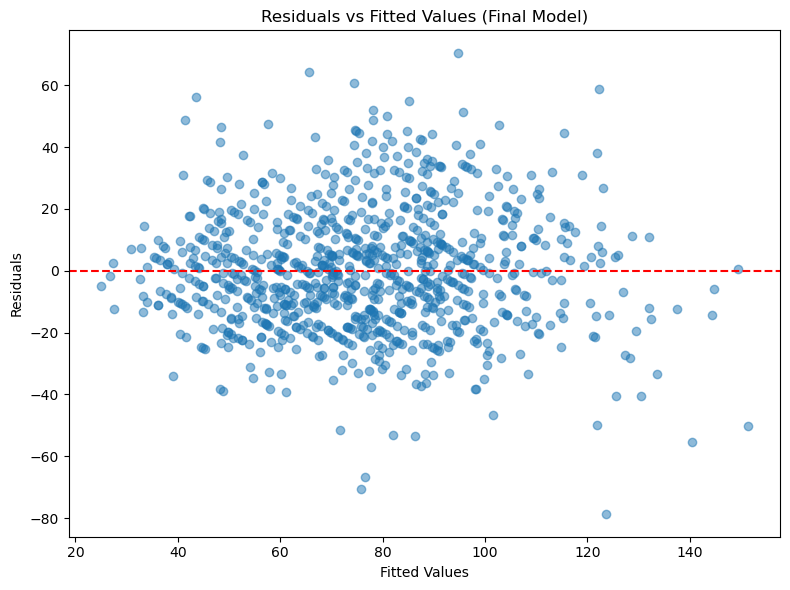

Variance Inflation Factor (VIF) for final model variables:
               feature         VIF
0                const  125.458760
4         capture_rate    2.166111
7            sp_attack    1.975702
6              defense    1.945441
8           sp_defense    1.896795
5                   hp    1.648949
19              rarity    1.588294
9                speed    1.537781
3            weight_kg    1.517860
2         percent_male    1.513555
16         votes_first    1.374441
17          evo_length    1.326975
15       against_fairy    1.296990
11       against_water    1.279609
18  has_mega_evolution    1.242050
10        against_fire    1.224422
14       against_ghost    1.198457
13        against_rock    1.181194
1                  gen    1.145834
12    against_psychict    1.078939


In [ ]:
# Drop specified columns from X_const_vif
cols_to_drop = [
    'percent_female', 'height_m', 'against_normal', 'against_electric',
    'against_grass', 'against_ice', 'against_poison', 'against_bug',
    'against_steel', 'has_gigantamax','num_abilities'
] #columns with p>>0.05
X_const_final = X_const_vif.drop(columns=cols_to_drop)

# Fit OLS linear regression
model_final = sm.OLS(y, X_const_final).fit()
print(model_final.summary())

# QQ plot of residuals
residuals_final = model_final.resid
sm.qqplot(residuals_final, line='45', fit=True)
plt.title("QQ Plot of Residuals (Final Model)")
plt.tight_layout()
plt.show()

# Residual plot (fitted values vs residuals)
fitted_final = model_final.fittedvalues
plt.figure(figsize=(8, 6))
plt.scatter(fitted_final, residuals_final, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Final Model)")
plt.tight_layout()
plt.show()

# VIF calculation
vif_final = pd.DataFrame()
vif_final["feature"] = X_const_final.columns
vif_final["VIF"] = [variance_inflation_factor(X_const_final.values, i) for i in range(X_const_final.shape[1])]
print("Variance Inflation Factor (VIF) for final model variables:")
print(vif_final.sort_values('VIF', ascending=False))

### Generalised Regression (poisson, gamma)

Poisson Regression Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 attack   No. Observations:                  898
Model:                            GLM   Df Residuals:                      878
Model Family:                 Poisson   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -5266.8
Date:                Mon, 27 Oct 2025   Deviance:                       5064.8
Time:                        19:19:41   Pearson chi2:                 4.94e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9980
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const   

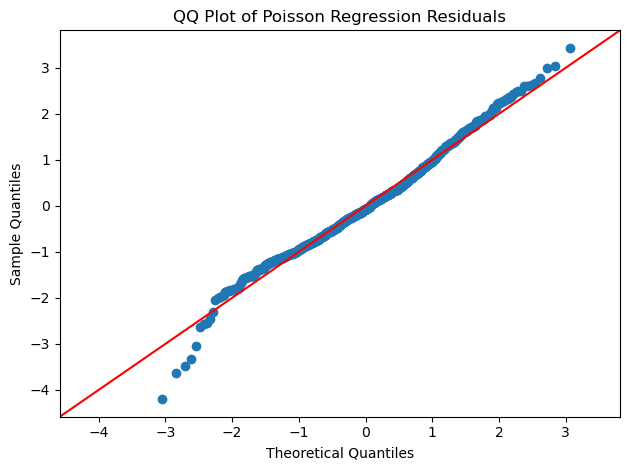

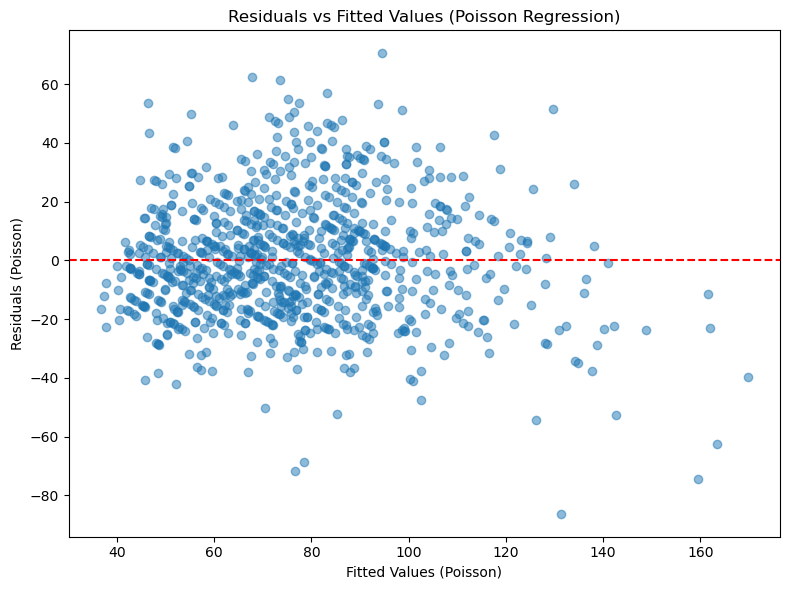

In [ ]:
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families

# Poisson regression (log link)
poisson_model = GLM(y, X_const_final, family=families.Poisson()).fit()
print("Poisson Regression Summary:")
print(poisson_model.summary())

# Residuals
poisson_residuals = poisson_model.resid_response

# QQ plot of residuals
sm.qqplot(poisson_residuals, line='45', fit=True)
plt.title("QQ Plot of Poisson Regression Residuals")
plt.tight_layout()
plt.show()

# Residual plot (fitted values vs residuals)
poisson_fitted = poisson_model.fittedvalues
plt.figure(figsize=(8, 6))
plt.scatter(poisson_fitted, poisson_residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Poisson)")
plt.ylabel("Residuals (Poisson)")
plt.title("Residuals vs Fitted Values (Poisson Regression)")
plt.tight_layout()
plt.show()


c:\Users\jenda\miniconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


Gamma Regression Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 attack   No. Observations:                  898
Model:                            GLM   Df Residuals:                      878
Model Family:                   Gamma   Df Model:                           19
Link Function:                    log   Scale:                        0.081010
Method:                          IRLS   Log-Likelihood:                -4013.9
Date:                Mon, 27 Oct 2025   Deviance:                       80.216
Time:                        19:19:01   Pearson chi2:                     71.1
No. Iterations:                    19   Pseudo R-squ. (CS):             0.6608
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const     

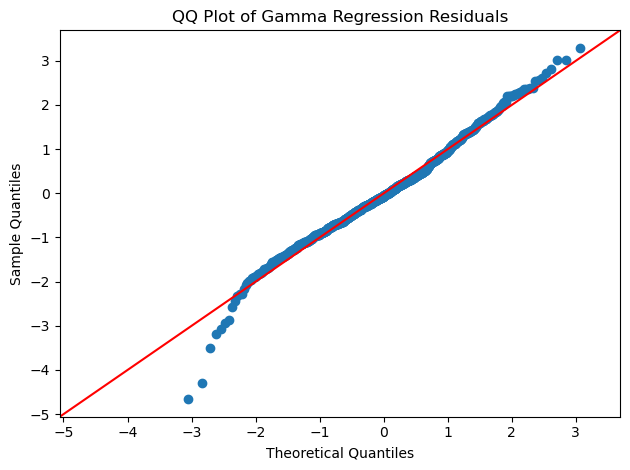

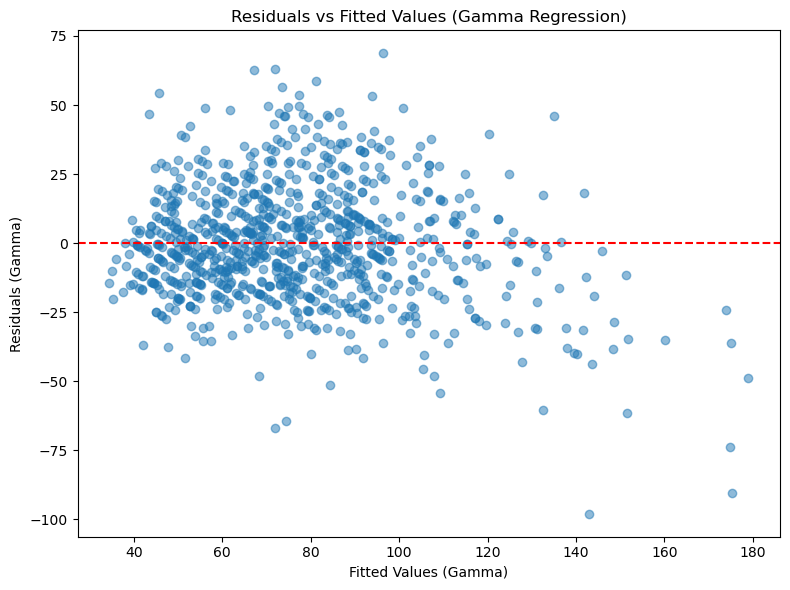

In [ ]:
# Gamma regression (log link) using X_const_final
gamma_model = GLM(y, X_const_final, family=families.Gamma(link=families.links.log())).fit()
print("Gamma Regression Summary:")
print(gamma_model.summary())

# Residuals
gamma_residuals = gamma_model.resid_response

# QQ plot of residuals
sm.qqplot(gamma_residuals, line='45', fit=True)
plt.title("QQ Plot of Gamma Regression Residuals")
plt.tight_layout()
plt.show()

# Residual plot (fitted values vs residuals)
gamma_fitted = gamma_model.fittedvalues
plt.figure(figsize=(8, 6))
plt.scatter(gamma_fitted, gamma_residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Gamma)")
plt.ylabel("Residuals (Gamma)")
plt.title("Residuals vs Fitted Values (Gamma Regression)")
plt.tight_layout()
plt.show()

### Comparison, summary

In [31]:
# Compare models by AIC
print("AIC Comparison:")
print(f"Linear Regression (Final): {model_final.aic:.2f}")
print(f"Poisson Regression: {poisson_model.aic:.2f}")
print(f"Gamma Regression: {gamma_model.aic:.2f}")

AIC Comparison:
Linear Regression (Final): 7958.60
Poisson Regression: 10573.58
Gamma Regression: 8067.86
